# Nifty Large Positive-Move Event Study

## Research objective
This notebook tests whether an unusually large positive daily move in the Nifty 50 index predicts a lower next-day return. The event is defined using information available at day t, while the target is measured on day t+1.

## Hypotheses
- Null hypothesis (H0): a large positive daily move does not predict a lower average next-day return relative to non-event days.
- Alternative hypothesis (H1): a large positive daily move predicts a lower average next-day return relative to non-event days.

## Event definition
- Event day: Daily return > 2%
- Target: Next trading day's close-to-close return
- Benchmark: All non-event days in the same sample

## Methodological framing
This is a one-sided event study designed to examine whether mean reversion or profit-taking follows exceptionally strong positive index moves. The main test is a Welch two-sample t-test because the event and non-event groups have different variance profiles.

## Dataset and coverage
- Instrument: Nifty 50 index (^NSEI)
- Source: Yahoo Finance
- Frequency: Daily
- Sample: 2010-01-01 to 2026-09-08
- Data handling: daily close, daily return, and next-day forward return are constructed explicitly to avoid look-ahead bias.


##### Download Data via yfinance

In [3]:
import yfinance as yf

In [4]:
ticker_data = yf.Ticker("^NSEI")

historical_df = ticker_data.history(
    start="2010-01-01",
    end="2026-09-08",
    interval="1d"
)

historical_df.to_csv("nifty_daily_data.csv")

print("Data downloaded")

Data downloaded


### Data loading and validation
This section loads the raw market data, standardizes the date index, and checks the integrity of the trading panel before constructing event variables.

Key quality checks include:
- raw row count and column coverage
- missing values and duplicates
- date ordering and trading-day continuity
- OHLC sanity checks
- numeric type validation for return construction


In [ ]:
import pandas as pd

# Read raw price data from the local CSV export.
df = pd.read_csv("nifty_daily_data.csv")

# Preserve a clean copy for validation and a transformed copy for analysis.
raw_df = df.copy()
print(f"Raw rows: {len(df)}")
print(f"Raw columns: {list(df.columns)}")
print(df.head())


In [6]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-01-04 00:00:00+05:30,5200.899902,5238.450195,5167.100098,5232.200195,0,0.0,0.0
1,2010-01-05 00:00:00+05:30,5277.149902,5288.350098,5242.399902,5277.899902,0,0.0,0.0
2,2010-01-06 00:00:00+05:30,5278.149902,5310.850098,5260.049805,5281.799805,0,0.0,0.0
3,2010-01-07 00:00:00+05:30,5281.799805,5302.549805,5244.750000,5263.100098,0,0.0,0.0
4,2010-01-08 00:00:00+05:30,5264.250000,5276.750000,5234.700195,5244.750000,0,0.0,0.0


In [7]:
df.shape

(4097, 8)

In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='str')

### check Missing value

In [ ]:
# Missing-data audit
missing_by_column = df.isna().sum()
print(missing_by_column)
print(f"Total missing values: {missing_by_column.sum()}")


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

#### Check duplicate values

In [ ]:
# Duplicate-date audit
print(f"Duplicate Date rows: {df['Date'].duplicated().sum()}")


np.int64(0)

#### Check OHLC consistency

In [ ]:
# OHLC sanity checks
print(f"High < Open: {(df['High'] < df['Open']).sum()}")
print(f"High < Close: {(df['High'] < df['Close']).sum()}")
print(f"Low > Open: {(df['Low'] > df['Open']).sum()}")
print(f"Low > Close: {(df['Low'] > df['Close']).sum()}")
print(f"High < Low: {(df['High'] < df['Low']).sum()}")

# A valid trading-day bar should satisfy high >= max(open, close) and low <= min(open, close).
assert (df['High'] < df['Low']).sum() == 0, "Data contains inverted bars"


0
0
0
0
0


In [12]:
df.dtypes

Date                str
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

#### Convert date(str) to date(datetime64)

In [ ]:
# Convert the raw date string to datetime and ensure temporal ordering.
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(df.dtypes)
print(f"Start date: {df['Date'].min()}")
print(f"End date: {df['Date'].max()}")
print(f"Total rows: {len(df)}")


Date            datetime64[us, UTC+05:30]
Open                              float64
High                              float64
Low                               float64
Close                             float64
Volume                              int64
Dividends                         float64
Stock Splits                      float64
dtype: object

#### Check daily date difference (Chronological order)

In [14]:
df["Date"].diff().head(10)

0      NaT
1   1 days
2   1 days
3   1 days
4   1 days
5   3 days
6   1 days
7   1 days
8   1 days
9   1 days
Name: Date, dtype: timedelta64[us]

In [ ]:
# Date continuity audit
non_positive_diff = (df['Date'].diff() <= pd.Timedelta(0)).sum()
print(f"Non-positive date gaps: {non_positive_diff}")
print(df['Date'].diff().head(10))


np.False_

### Constructing the event and target variables
The analysis requires three concepts to be represented explicitly:
1. Daily return at time t
2. Event indicator for a large positive move at time t
3. Forward return from t to t+1, used as the dependent variable

This ensures the event is defined using information available at the close of day t and the target is measured only after the event date.


In [ ]:
df["Daily_return"] = df["Close"].pct_change()

In [17]:
df[["Date","Close","Daily_return"]].head(10)

,Date,Close,Daily_return
0,2010-01-04 00:00:00+05:30,5232.200195,NaN
1,2010-01-05 00:00:00+05:30,5277.899902,0.008734
2,2010-01-06 00:00:00+05:30,5281.799805,0.000739
3,2010-01-07 00:00:00+05:30,5263.100098,-0.003540
4,2010-01-08 00:00:00+05:30,5244.750000,-0.003487
5,2010-01-11 00:00:00+05:30,5249.399902,0.000887
6,2010-01-12 00:00:00+05:30,5210.399902,-0.007429
7,2010-01-13 00:00:00+05:30,5233.950195,0.004520
8,2010-01-14 00:00:00+05:30,5259.899902,0.004958
9,2010-01-15 00:00:00+05:30,5252.200195,-0.001464


#### Create new column Large Move > 2%

In [18]:
df["Large_Move"] = df["Daily_return"] > 0.02

#### Create new day return column - shift daily return to previous row

In [19]:
df["Next_Day_Return"] = df["Daily_return"].shift(-1)

In [20]:
df[["Date", "Daily_return", "Large_Move", "Next_Day_Return"]].head(10)

,Date,Daily_return,Large_Move,Next_Day_Return
0,2010-01-04 00:00:00+05:30,NaN,False,0.008734
1,2010-01-05 00:00:00+05:30,0.008734,False,0.000739
2,2010-01-06 00:00:00+05:30,0.000739,False,-0.003540
3,2010-01-07 00:00:00+05:30,-0.003540,False,-0.003487
4,2010-01-08 00:00:00+05:30,-0.003487,False,0.000887
5,2010-01-11 00:00:00+05:30,0.000887,False,-0.007429
6,2010-01-12 00:00:00+05:30,-0.007429,False,0.004520
7,2010-01-13 00:00:00+05:30,0.004520,False,0.004958
8,2010-01-14 00:00:00+05:30,0.004958,False,-0.001464
9,2010-01-15 00:00:00+05:30,-0.001464,False,0.004312


#### Check more than 2% move

In [ ]:
# Event count and basic sample composition
print(f"Event observations: {df['Large_Move'].sum()}")
print(f"Non-event observations: {(~df['Large_Move']).sum()}")
print(f"Event rate: {df['Large_Move'].mean():.2%}")


np.int64(99)

#### mean of next-day returns after large moves

In [ ]:
event_mean = df[df["Large_Move"] == True]["Next_Day_Return"].mean()

#### Non event day mean

In [23]:
non_event_mean = df[df["Large_Move"] == False]["Next_Day_Return"].mean()

In [24]:
effect = event_mean - non_event_mean

In [25]:
effect

np.float64(-0.0004017068921197611)

#### Same number of event count kar rhe h 

In [26]:
event_n = df[df["Large_Move"] == True]["Next_Day_Return"].count()
event_n

np.int64(99)

#### Number of non event days

In [27]:
non_event_n = df[df["Large_Move"] == False]["Next_Day_Return"].count()
non_event_n

np.int64(3997)

#### Drop Nan values in both daily return and nect day return column 

In [28]:
analysis_df = df.dropna(subset=["Daily_return","Next_Day_Return"])

In [29]:
analysis_df.shape

(4095, 11)

#### Now calculate Std of event days

In [30]:
event_std = analysis_df[analysis_df["Large_Move"] == True]["Next_Day_Return"].std()

#### std of non event days

In [31]:
non_event_std = analysis_df[analysis_df["Large_Move"] == False]["Next_Day_Return"].std()

#### Calculate standard error 
se = std/sqrt(n)

In [32]:
from math import sqrt
event_SE = event_std / sqrt(event_n)
event_SE

np.float64(0.0022331314713334763)

In [33]:
non_event_SE = non_event_std / sqrt(non_event_n)
non_event_SE

np.float64(0.00015649790075673926)

#### Standard error difference
SE_diff = sqrt(event_SE ** 2 + non_event_SE ** 2) 

In [34]:
SE_diff = sqrt(event_SE**2 + non_event_SE**2)
SE_diff

0.002238608443029125

#### Now calculate t-stats
t-stats = effect / SE_diff

In [35]:
t_stat = effect / SE_diff
t_stat


np.float64(-0.17944491068576512)

#### Now calculate p-value

In [ ]:
from scipy import stats

event_returns = analysis_df[analysis_df["Large_Move"] == True]["Next_Day_Return"]

non_event_returns = analysis_df[analysis_df["Large_Move"] == False]["Next_Day_Return"]

result = stats.ttest_ind(event_returns,non_event_returns,equal_var=False,alternative="less")

print(result)


TtestResult(statistic=np.float64(-0.17851684710315877), pvalue=np.float64(0.42934101224393884), df=np.float64(98.96514428183762))

#### Calculate Confidence interval

In [ ]:
t_critical = stats.t.ppf(0.975, result.df)
t_critical

np.float64(1.9842255968661675)

In [38]:
margin_error = t_critical * SE_diff
margin_error

np.float64(0.004441904174019107)

In [39]:
lower = effect - margin_error
upper = effect + margin_error

lower, upper

(np.float64(-0.004843611066138868), np.float64(0.0040401972818993465))

In [ ]:
# Updated Welch test and one-sided inference


print(f"Event observations: {event_n}")
print(f"Non-event observations: {non_event_n}")
print(f"Event mean: {event_returns.mean():.6%}")
print(f"Non-event mean: {non_event_returns.mean():.6%}")
print(f"Effect: {effect:.6%} ({effect * 10000:.2f} bps)")
print(f"Welch t-statistic: {result.statistic:.4f}")
print(f"One-sided p-value: {result.pvalue:.4f}")
print(f"95% CI lower bound: {lower:.6%}")
print(f"95% CI upper bound: {upper:.6%}")

if result.pvalue < 0.05:
    print("Reject H0: evidence supports a lower next-day return.")
else:
    print("Fail to reject H0: insufficient evidence of a lower next-day return.")


Event observations: 99
Non-event observations: 3997
Event mean: 0.003162%
Non-event mean: 0.043124%
Effect: -0.040171% (-4.02 bps)
Welch t-statistic: -0.1785
One-sided p-value: 0.4293
95% CI lower bound: -0.484361%
95% CI upper bound: 0.404020%
Fail to reject H0: insufficient evidence of a lower next-day return.


#### Exploratory Data Analysis (EDA)

check mean, median, STD, min , max , quantile

In [41]:
event_median = event_returns.median()
non_event_median = non_event_returns.median()
print(event_median)
print(non_event_median)

0.0025171379889952217
0.0004916843303464091


In [42]:
event_returns_min = event_returns.min()
event_returns_max = event_returns.max()

non_event_returns_min = non_event_returns.min()
non_event_returns_max = non_event_returns.max()

print(event_returns_min)
print(event_returns_max)
print(non_event_returns_min)
print(non_event_returns_max)

-0.12980466070471242
0.06624746894667499
-0.08301938801064712
0.08763210467115035


In [43]:
event_returns.quantile([0.25, 0.50, 0.75])

0.25   -0.005217
0.50    0.002517
0.75    0.009909
Name: Next_Day_Return, dtype: float64

In [44]:
non_event_returns.quantile([0.25, 0.50, 0.75])

0.25   -0.004762
0.50    0.000492
0.75    0.005943
Name: Next_Day_Return, dtype: float64

#### event IQR and Non event IQR 
IQR(inter quantile range) = q3 - q1

In [45]:
event_iqr = event_returns.quantile(0.75) - event_returns.quantile(0.25)

non_event_iqr = non_event_returns.quantile(0.75) - non_event_returns.quantile(0.25)

print(event_iqr)
print(non_event_iqr)

0.015125894662675998
0.010704673359578476


##### outlier boundaries

##### Lower=Q1−1.5×IQR
##### Upper=Q3+1.5×IQR

In [46]:
event_q1 = event_returns.quantile(0.25)
event_q3 = event_returns.quantile(0.75)

event_lower = event_q1 - 1.5 * event_iqr
event_upper = event_q3 + 1.5 * event_iqr

print(event_lower)
print(event_upper)

-0.027905907314774048
0.032597671335929945


In [47]:
# Non-event outlier boundaries
non_event_q1 = non_event_returns.quantile(0.25)
non_event_q3 = non_event_returns.quantile(0.75)

non_event_lower = non_event_q1 - 1.5 * non_event_iqr
non_event_upper = non_event_q3 + 1.5 * non_event_iqr

print(non_event_lower)
print(non_event_upper)

-0.020819020871879756
0.021999672566434147


In [48]:
event_outliers = event_returns[(event_returns < event_lower) | (event_returns > event_upper)]

non_event_outliers = non_event_returns[(non_event_returns < non_event_lower) | (non_event_returns > non_event_upper)]

print("Event potential outliers:", len(event_outliers))
print("Non-event potential outliers:", len(non_event_outliers))

Event potential outliers: 7
Non-event potential outliers: 157


In [49]:
print(f"Event potential outlier %: {len(event_outliers) / len(event_returns):.2%}")
print(f"Non-event potential outlier %: {len(non_event_outliers) / len(non_event_returns):.2%}")

Event potential outlier %: 7.07%
Non-event potential outlier %: 3.93%


In [50]:
print(event_outliers.sort_values())

2498   -0.129805
2493   -0.076121
3535   -0.059294
2523   -0.057445
2505   -0.040005
2501    0.038904
2500    0.066247
Name: Next_Day_Return, dtype: float64


In [51]:
print(non_event_outliers.sort_values())

2491   -0.083019
1378   -0.059151
2495   -0.055565
2489   -0.048956
2977   -0.047781
          ...   
2509    0.041509
2712    0.047424
2375    0.053191
2497    0.058329
2507    0.087632
Name: Next_Day_Return, Length: 157, dtype: float64


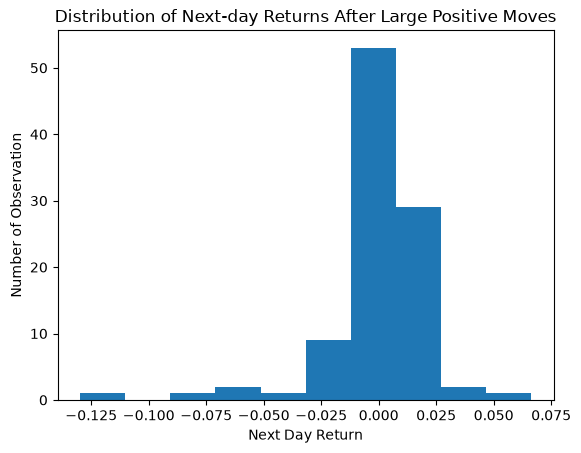

In [52]:
import matplotlib.pyplot as plt
plt.hist(event_returns)

plt.xlabel("Next Day Return")
plt.ylabel("Number of Observation")
plt.title("Distribution of Next-day Returns After Large Positive Moves")

plt.show()

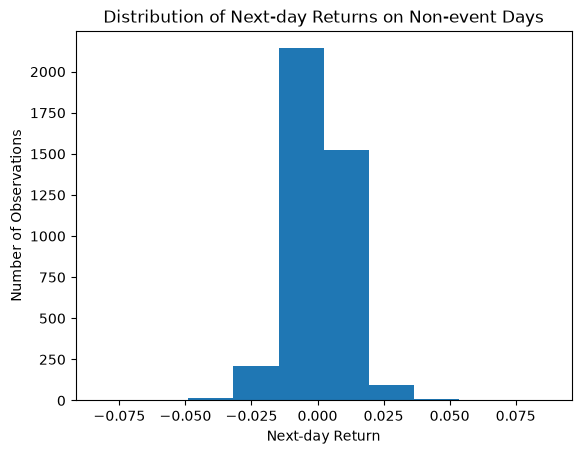

In [53]:
plt.hist(non_event_returns)

plt.xlabel("Next-day Return")
plt.ylabel("Number of Observations")
plt.title("Distribution of Next-day Returns on Non-event Days")

plt.show()

#### Skewness

In [54]:
event_skew = event_returns.skew()
event_skew

np.float64(-2.5201532830512936)

In [55]:
non_event_skew = non_event_returns.skew()
non_event_skew

np.float64(-0.08243148459922355)

#### Kurtosis

In [56]:
event_kurt = event_returns.kurt()
event_kurt

np.float64(13.329090267009246)

In [57]:
non_event_kurt = non_event_returns.kurt()
non_event_kurt

np.float64(5.134664322615479)

#### Event and non event return comparison 

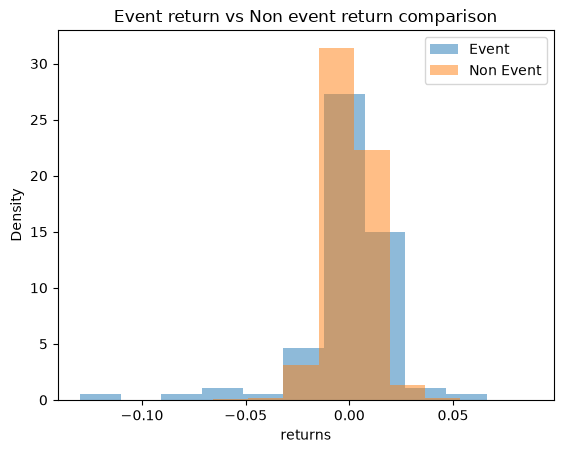

In [58]:
import matplotlib.pyplot as plt

plt.hist(event_returns,density=True,alpha=0.5,label="Event")
plt.hist(non_event_returns,density=True,alpha= 0.5,label="Non Event")
plt.xlabel("returns")
plt.ylabel("Density")
plt.title("Event return vs Non event return comparison")
plt.legend()
plt.show()

#### Create same bin edge for better comparison 

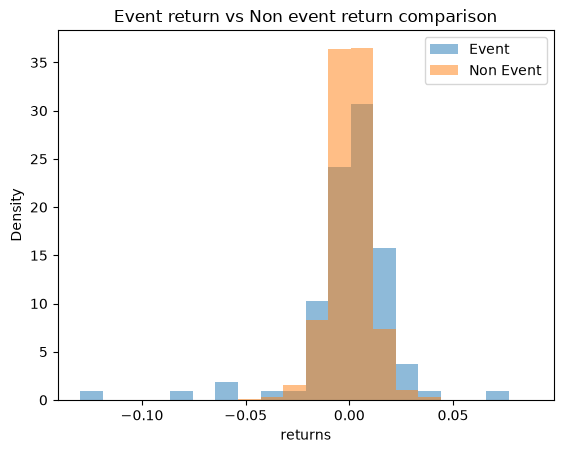

In [59]:
import numpy as np
import matplotlib.pyplot as plt

bin_edges = np.linspace(min(event_returns_min,non_event_returns_min),max(event_returns_max,non_event_returns_max),21)

plt.hist(event_returns,bins=bin_edges,density=True,alpha=0.5,label="Event")
plt.hist(non_event_returns,bins=bin_edges,density=True,alpha= 0.5,label="Non Event")
plt.xlabel("returns")
plt.ylabel("Density")
plt.title("Event return vs Non event return comparison")
plt.legend()
plt.show()

#### Mean vs median vs skewness

The event distribution is strongly negatively skewed, but descriptive statistics alone do not provide evidence that the event mean is significantly lower than the non-event mean.

In [60]:
print("Event Mean:", event_mean)
print("Event Median:", event_median)
print("Event Skewness:", event_skew)

print("Non-Event Mean:", non_event_mean)
print("Non-Event Median:", non_event_median)
print("Non-Event Skewness:", non_event_skew)

Event Mean: 3.161531817186707e-05
Event Median: 0.0025171379889952217
Event Skewness: -2.5201532830512936
Non-Event Mean: 0.00043332221029162817
Non-Event Median: 0.0004916843303464091
Non-Event Skewness: -0.08243148459922355


#### SD vs IQR

In [61]:
print("Event SD:",event_std)
print("Non Event SD:",non_event_std)

print("Event IQR:",event_iqr)
print("Non Event IQR:",non_event_iqr)

Event SD: 0.02221937759384231
Non Event SD: 0.009894083938710094
Event IQR: 0.015125894662675998
Non Event IQR: 0.010704673359578476


Event returns have higher SD (2.22%) and IQR (1.51%) than non-event returns (0.99% and 1.07%), showing greater dispersion.

This indicates higher variability after large positive moves, but it does not imply lower next-day returns.


#### Outliers

In [62]:
print("Event Outliers:",event_outliers)
print("Non Event Outliers:",non_event_outliers)

Event Outliers: 2493   -0.076121
2498   -0.129805
2500    0.066247
2501    0.038904
2505   -0.040005
2523   -0.057445
3535   -0.059294
Name: Next_Day_Return, dtype: float64
Non Event Outliers: 12     -0.024427
15     -0.030911
22     -0.026149
83      0.034984
90     -0.028927
          ...   
3982   -0.026038
3985   -0.020889
3986   -0.021394
3991    0.037784
4052   -0.021175
Name: Next_Day_Return, Length: 157, dtype: float64


In [63]:
event_outlier_pct = (len(event_outliers) / len(event_returns)) * 100
non_event_outlier_pct = (len(non_event_outliers) / len(non_event_returns)) * 100

print("Event Outlier %:", event_outlier_pct)
print("Non Event Outlier %:", non_event_outlier_pct)

Event Outlier %: 7.07070707070707
Non Event Outlier %: 3.9289289289289293


# Advanced exploratory analysis
## Research-grade diagnostics

The following cells audit data quality, describe the return distributions, check whether the event effect is stable over time, and add robustness diagnostics. All return variables are defined as close-to-close returns. The event is based on information available at the close of day t, while the target is the return measured on day t+1.

This section is intended to separate descriptive evidence from causal or predictive claims. It should be read as a robustness audit, not as confirmation of trading profitability.


In [ ]:
# Rebuild the analysis frame explicitly so the downstream diagnostics use a complete, consistent sample.
analysis_df = df.loc[:, ["Date", "Close", "Daily_return", "Large_Move", "Next_Day_Return"]].dropna().copy()
analysis_df["Year"] = analysis_df["Date"].dt.year
analysis_df["Month"] = analysis_df["Date"].dt.month
analysis_df["Weekday"] = analysis_df["Date"].dt.day_name()

quality_report = pd.DataFrame({
    "rows": [len(df), len(analysis_df)],
    "start": [df["Date"].min(), analysis_df["Date"].min()],
    "end": [df["Date"].max(), analysis_df["Date"].max()],
    "missing_values": [df.isna().sum().sum(), analysis_df.isna().sum().sum()],
    "duplicate_dates": [df["Date"].duplicated().sum(), analysis_df["Date"].duplicated().sum()],
}, index=["raw_data", "analysis_sample"])

print(quality_report)


,rows,start,end,missing_values,duplicate_dates
raw_data,4097,2010-01-04 00:00:00+05:30,2026-09-07 00:00:00+05:30,2,0
analysis_sample,4095,2010-01-05 00:00:00+05:30,2026-09-04 00:00:00+05:30,0,0


### Distribution and event diagnostics

Returns are reported in decimal form for calculations and in basis points or percentages for presentation. The table below separates unconditional market behavior from the conditional event sample.

In [ ]:
grouped = analysis_df.groupby("Large_Move")["Next_Day_Return"]
summary = grouped.agg(
    observations="count",
    mean="mean",
    median="median",
    volatility="std",
    minimum="min",
    maximum="max",
    skewness="skew",
    excess_kurtosis="kurt",
)
summary["win_rate"] = grouped.apply(lambda values: (values > 0).mean())
summary["mean_bps"] = summary["mean"] * 10000
summary["volatility_bps"] = summary["volatility"] * 10000
summary.index = ["Non-event", "Event"]
summary = summary.round({
    "mean": 6,
    "median": 6,
    "volatility": 6,
    "minimum": 6,
    "maximum": 6,
    "skewness": 3,
    "excess_kurtosis": 3,
    "win_rate": 3,
    "mean_bps": 2,
    "volatility_bps": 2,
})
print(summary)


,observations,mean,median,volatility,minimum,maximum,skewness,excess_kurtosis,win_rate,mean_bps,volatility_bps
Non-event,3996,0.000431,0.000492,0.009894,-0.083019,0.087632,-0.082,5.135,0.529,4.31,98.94
Event,99,0.000032,0.002517,0.022219,-0.129805,0.066247,-2.520,13.329,0.566,0.32,222.19


### Visual diagnostics

The plots show price growth, volatility clustering, the two conditional return distributions, and the event effect by calendar year. The event series is intentionally plotted with the same axes as the control series so scale differences remain visible.

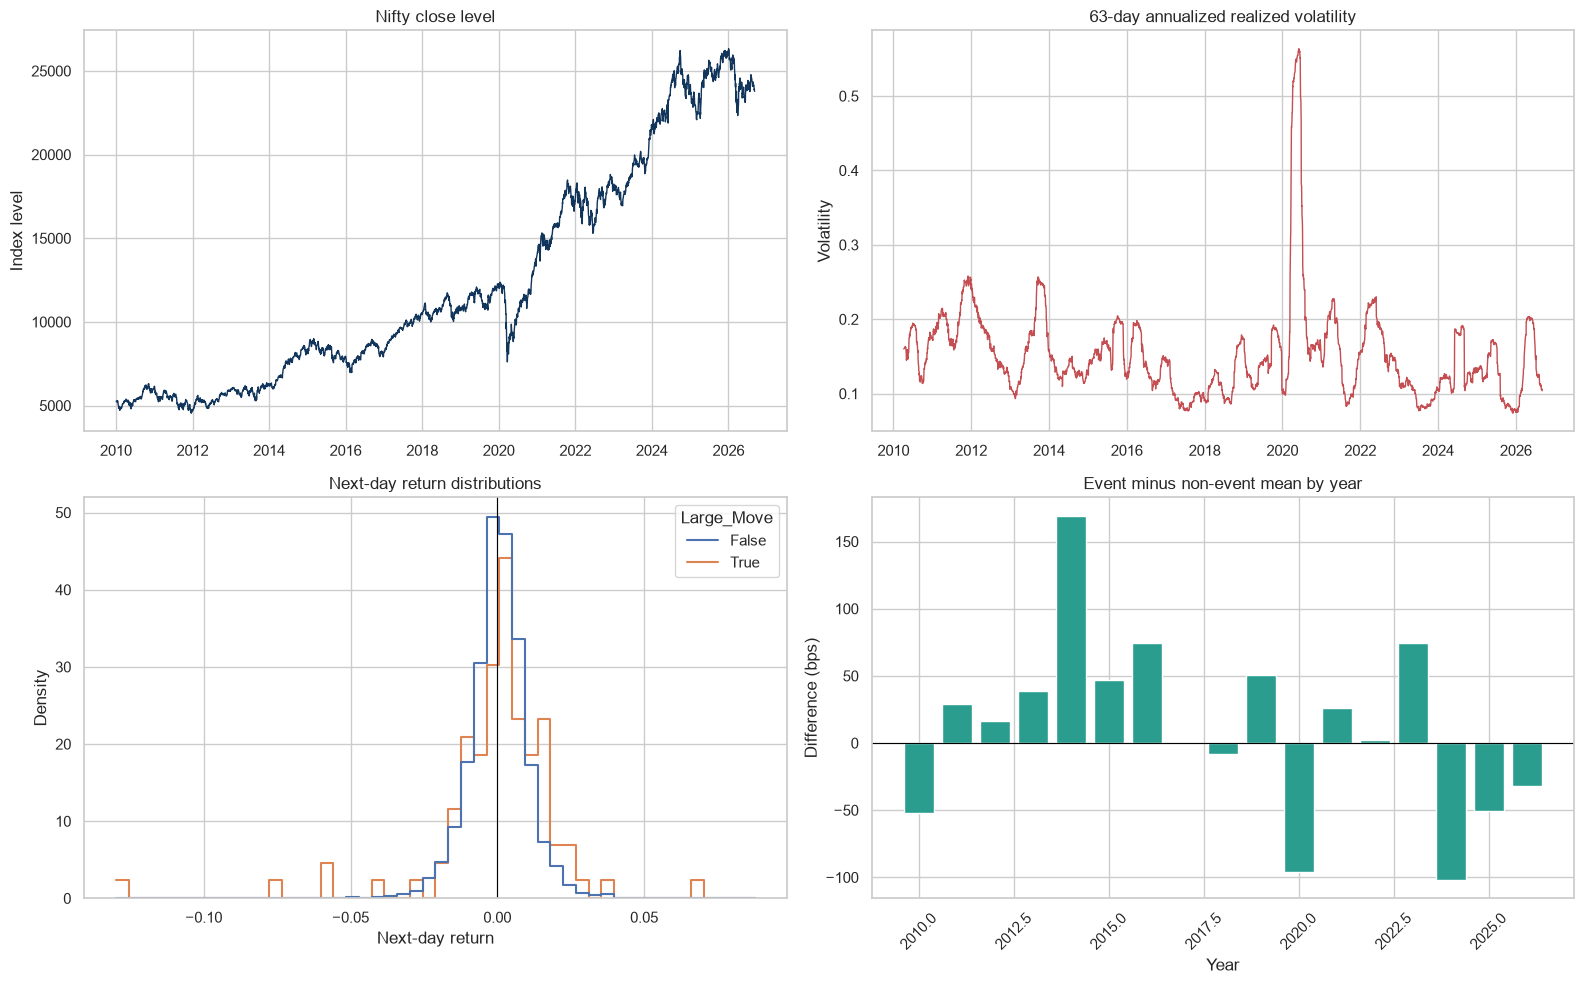

In [66]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(df["Date"], df["Close"], color="#12355B", linewidth=1)
axes[0, 0].set_title("Nifty close level")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Index level")

rolling_volatility = analysis_df["Daily_return"].rolling(63).std() * np.sqrt(252)
axes[0, 1].plot(analysis_df["Date"], rolling_volatility, color="#C44E52", linewidth=1)
axes[0, 1].set_title("63-day annualized realized volatility")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Volatility")

sns.histplot(data=analysis_df, x="Next_Day_Return", hue="Large_Move", bins=50, stat="density", common_norm=False, element="step", fill=False, ax=axes[1, 0])
axes[1, 0].axvline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("Next-day return distributions")
axes[1, 0].set_xlabel("Next-day return")

annual_effect = analysis_df.groupby("Year").apply(
    lambda frame: pd.Series({
        "effect": frame.loc[frame["Large_Move"], "Next_Day_Return"].mean() - frame.loc[~frame["Large_Move"], "Next_Day_Return"].mean(),
        "events": frame["Large_Move"].sum(),
    }), include_groups=False
).reset_index()
axes[1, 1].bar(annual_effect["Year"], annual_effect["effect"] * 10000, color="#2A9D8F")
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Event minus non-event mean by year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Difference (bps)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Stability, dependence, and robustness

A useful event study should answer three questions beyond the headline mean: does the event occur evenly through the sample, is the effect persistent across time, and would the observed difference be unusual under random group assignment?

In [ ]:
annual_summary = analysis_df.groupby("Year").agg(
    observations=("Next_Day_Return", "size"),
    events=("Large_Move", "sum"),
    mean_return=("Next_Day_Return", "mean"),
)
annual_summary["event_rate"] = annual_summary["events"] / annual_summary["observations"]
annual_summary["event_rate_pct"] = annual_summary["event_rate"] * 100
annual_summary["mean_return_bps"] = annual_summary["mean_return"] * 10000

print("Annual event frequency and unconditional return:")
print(annual_summary[["observations", "events", "event_rate_pct", "mean_return_bps"]].round(2))

print("\nSerial dependence diagnostics:")
print(f"Daily return lag-1 autocorrelation: {analysis_df['Daily_return'].autocorr():.4f}")
print(f"Next-day return lag-1 autocorrelation: {analysis_df['Next_Day_Return'].autocorr():.4f}")
print(f"Event indicator lag-1 autocorrelation: {analysis_df['Large_Move'].astype(int).autocorr():.4f}")


Annual event frequency and unconditional return:


,observations,events,event_rate_pct,mean_return_bps
Year,,,,
2010,249,6,2.41,6.72
2011,242,17,7.02,-9.68
2012,242,10,4.13,9.94
2013,247,11,4.45,2.16
2014,240,2,0.83,12.82
2015,244,3,1.23,-2.52
2016,244,5,2.05,2.44
2017,248,0,0.00,10.02
2018,245,2,0.82,1.67



Serial dependence diagnostics:
Daily return lag-1 autocorrelation: 0.0051
Next-day return lag-1 autocorrelation: 0.0051
Event indicator lag-1 autocorrelation: 0.0477


### Resampling diagnostics

The Welch test is a useful baseline, but event observations are sparse and heavy-tailed. Bootstrap confidence intervals and a permutation test provide distribution-light cross-checks; they are diagnostics, not a substitute for an out-of-sample trading evaluation.

In [68]:
rng = np.random.default_rng(42)
event_values = event_returns.to_numpy()
non_event_values = non_event_returns.to_numpy()

bootstrap_effects = np.empty(10000)
for iteration in range(len(bootstrap_effects)):
    event_sample = rng.choice(event_values, size=len(event_values), replace=True)
    non_event_sample = rng.choice(non_event_values, size=len(non_event_values), replace=True)
    bootstrap_effects[iteration] = event_sample.mean() - non_event_sample.mean()

bootstrap_ci = np.quantile(bootstrap_effects, [0.025, 0.975])
pooled = np.concatenate([event_values, non_event_values])
observed_effect = event_values.mean() - non_event_values.mean()
permutation_effects = np.empty(10000)
for iteration in range(len(permutation_effects)):
    shuffled = rng.permutation(pooled)
    permutation_effects[iteration] = shuffled[:len(event_values)].mean() - shuffled[len(event_values):].mean()
permutation_pvalue = (np.abs(permutation_effects) >= abs(observed_effect)).mean()

robustness = pd.Series({
    "observed_effect_bps": observed_effect * 10000,
    "bootstrap_95pct_lower_bps": bootstrap_ci[0] * 10000,
    "bootstrap_95pct_upper_bps": bootstrap_ci[1] * 10000,
    "permutation_two_sided_pvalue": permutation_pvalue,
    "event_median_minus_non_event_median_bps": (np.median(event_values) - np.median(non_event_values)) * 10000,
})
robustness.round(4)

observed_effect_bps                        -3.9963
bootstrap_95pct_lower_bps                 -49.5805
bootstrap_95pct_upper_bps                  37.5603
permutation_two_sided_pvalue                0.6926
event_median_minus_non_event_median_bps    20.2545
dtype: float64

### Quant interpretation and limitations

The event sample is small relative to the full history and is not uniformly distributed across years. The following cell records the evidence in a reproducible form. A trading conclusion would still require transaction costs, signal timing, walk-forward validation, and controls for volatility regime and overlapping signals.

In [69]:
print("Research conclusion")
print("- Event definition: daily close-to-close return > 2.00%.")
print(f"- Complete event observations: {len(event_values)}; non-event observations: {len(non_event_values)}.")
print(f"- Mean effect: {observed_effect * 10000:.2f} bps (event minus non-event).")
print(f"- Welch one-sided p-value: {result.pvalue:.4f}.")
print(f"- Bootstrap 95% interval: [{bootstrap_ci[0] * 10000:.2f}, {bootstrap_ci[1] * 10000:.2f}] bps.")
print(f"- Permutation two-sided p-value: {permutation_pvalue:.4f}.")

if result.pvalue < 0.05 and bootstrap_ci[1] < 0:
    print("Interpretation: evidence is consistent with a lower next-day return after the event.")
else:
    print("Interpretation: the sample does not provide robust evidence of a lower next-day return.")
print("- Next step: test the signal out of sample with costs and volatility-regime controls.")

Research conclusion
- Event definition: daily close-to-close return > 2.00%.
- Complete event observations: 99; non-event observations: 3996.
- Mean effect: -4.00 bps (event minus non-event).
- Welch one-sided p-value: 0.4293.
- Bootstrap 95% interval: [-49.58, 37.56] bps.
- Permutation two-sided p-value: 0.6926.
Interpretation: the sample does not provide robust evidence of a lower next-day return.
- Next step: test the signal out of sample with costs and volatility-regime controls.


#### threshold robustness

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind


def robustness(threshold):
    event = analysis_df["Daily_return"] > threshold

    event_returns = analysis_df.loc[event, "Next_Day_Return"]
    non_event_returns = analysis_df.loc[~event, "Next_Day_Return"]

    event_n = len(event_returns)
    non_event_n = len(non_event_returns)

    event_mean = event_returns.mean()
    non_event_mean = non_event_returns.mean()

    effect = event_mean - non_event_mean

    t_stat, p_value = ttest_ind(
        event_returns,
        non_event_returns,
        equal_var=False,
        alternative="less"
    )

    return {
        "Threshold": threshold * 100,
        "Event_N": event_n,
        "Non_Event_N": non_event_n,
        "Event_Mean": event_mean,
        "Non_Event_Mean": non_event_mean,
        "Effect": effect,
        "Effect_bps": effect * 10000,
        "t_stat": t_stat,
        "p_value": p_value
    }

threshold_list = [0.015, 0.02, 0.025, 0.03]

results = []

for threshold in threshold_list:
    results.append(robustness(threshold))


robustness_df = pd.DataFrame(results)

robustness_df

,Threshold,Event_N,Non_Event_N,Event_Mean,Non_Event_Mean,Effect,Effect_bps,t_stat,p_value
0,1.5,249,3846,0.001803,0.000332,0.001470,14.704831,1.417131,0.921179
1,2.0,99,3996,0.000032,0.000431,-0.000400,-3.996296,-0.178517,0.429341
2,2.5,51,4044,-0.002483,0.000458,-0.002941,-29.414978,-0.717146,0.238306
3,3.0,27,4068,-0.010353,0.000493,-0.010846,-108.458285,-1.571453,0.064078


The robustness table shows the direction of the estimated effect is highly sensitive to the event threshold. As the threshold rises, the event sample becomes smaller and the estimated mean effect becomes more negative, but the statistical evidence does not cross the 5% level for any threshold tested.

This is an important limitation: the result is not stable to reasonable alternative definitions of a large positive move, which weakens the case for a reliable mean-reversion signal.


### Time stability / structural break check
The sample is split into two chronological halves to assess whether the event effect is stable across different market regimes and periods.


In [ ]:
mid = len(analysis_df) // 2
first_half = analysis_df.iloc[:mid].copy()
second_half = analysis_df.iloc[mid:].copy()

print("Total observations:", len(analysis_df))
print("Midpoint:", mid)
print("First half:", len(analysis_df.iloc[:mid]))
print("Second half:", len(analysis_df.iloc[mid:]))

Total observations: 4095
Midpoint: 2047
First half: 2047
Second half: 2048


In [76]:
first_half = analysis_df.iloc[:mid]
second_half = analysis_df.iloc[mid:]

first_event_n = (first_half["Daily_return"] > 0.02).sum()
second_event_n = (second_half["Daily_return"] > 0.02).sum()

print("First-half events:", first_event_n)
print("Second-half events:", second_event_n)

First-half events: 54
Second-half events: 45


In [77]:
first_event_returns = first_half[first_half["Daily_return"] > 0.02]["Next_Day_Return"]
first_non_event_returns = first_half[first_half["Daily_return"] <= 0.02]["Next_Day_Return"]

second_event_returns = second_half[second_half["Daily_return"] > 0.02]["Next_Day_Return"]
second_non_event_returns = second_half[second_half["Daily_return"] <= 0.02]["Next_Day_Return"]

In [78]:
first_event_mean = first_event_returns.mean()
first_non_event_mean = first_non_event_returns.mean()

second_event_mean = second_event_returns.mean()
second_non_event_mean = second_non_event_returns.mean()

print("First-half event mean:", first_event_mean)
print("First-half non-event mean:", first_non_event_mean)

print("Second-half event mean:", second_event_mean)
print("Second-half non-event mean:", second_non_event_mean)

First-half event mean: 0.0029510614459528814
First-half non-event mean: 0.0003245428503364917
Second-half event mean: -0.00347172003516535
Second-half non-event mean: 0.0005374142059596633


In [79]:
first_effect = first_event_mean - first_non_event_mean
second_effect = second_event_mean - second_non_event_mean

print("First-half effect:", first_effect)
print("First-half effect (bps):", first_effect * 10000)

print("Second-half effect:", second_effect)
print("Second-half effect (bps):", second_effect * 10000)

First-half effect: 0.00262651859561639
First-half effect (bps): 26.2651859561639
Second-half effect: -0.004009134241125013
Second-half effect (bps): -40.09134241125013


In [80]:
from scipy.stats import ttest_ind

t_stat_first, p_value_first = ttest_ind(
    first_event_returns,
    first_non_event_returns,
    equal_var=False,
    alternative="less"
)

print("First-half t-stat:", t_stat_first)
print("First-half p-value:", p_value_first)

First-half t-stat: 1.8516156840819145
First-half p-value: 0.9653075512482153


In [ ]:
from scipy.stats import ttest_ind

t_stat_second,p_value_second = ttest_ind(second_event_returns,second_non_event_returns,equal_var=False,alternative="less")

print("Second-half t-stat:",t_stat_second)
print("Second-half p-value:",p_value_second)

Second-half t-stat: -0.8720494384232405
Second-half p-value: 0.19394680236956988


The estimated effect changes sign across the two halves of the sample. This instability matters because a credible predictive relationship should survive basic time-splitting checks rather than relying on one favorable period.

A sign reversal across time, combined with non-significant p-values, suggests that the observed result is not a robust feature of the market data.


### Volatility-regime check
The next diagnostic asks whether the effect differs when the market is relatively calm versus turbulent. This is important because event studies often interact with volatility regime and risk compensation.


In [ ]:
analysis_df["Rolling_Vol_20"] = analysis_df["Daily_return"].rolling(20).std().shift(1)
analysis_df["Rolling_Vol_20"].describe()

count    4075.000000
mean        0.009289
std         0.004609
min         0.003169
25%         0.006497
50%         0.008403
75%         0.010853
max         0.055963
Name: Rolling_Vol_20, dtype: float64

In [91]:
vol_median = analysis_df["Rolling_Vol_20"].median()

print("Median pre-event volatility:", vol_median)

low_vol = analysis_df["Rolling_Vol_20"] <= vol_median
high_vol = analysis_df["Rolling_Vol_20"] > vol_median

event = analysis_df["Daily_return"] > 0.02

print("Low-vol observations:", low_vol.sum())
print("High-vol observations:", high_vol.sum())

print("Low-vol events:", (low_vol & event).sum())
print("High-vol events:", (high_vol & event).sum())

Median pre-event volatility: 0.008403393212559132
Low-vol observations: 2038
High-vol observations: 2037
Low-vol events: 13
High-vol events: 86


In [92]:
low_event_returns = analysis_df.loc[low_vol & event, "Next_Day_Return"]

low_non_event_returns = analysis_df.loc[low_vol & ~event, "Next_Day_Return"]

high_event_returns = analysis_df.loc[high_vol & event, "Next_Day_Return"]

high_non_event_returns = analysis_df.loc[high_vol & ~event, "Next_Day_Return"]

In [93]:
print("Low-vol Event N:", len(low_event_returns))
print("Low-vol Event Mean:", low_event_returns.mean())

print("Low-vol Non-event N:", len(low_non_event_returns))
print("Low-vol Non-event Mean:", low_non_event_returns.mean())

print("High-vol Event N:", len(high_event_returns))
print("High-vol Event Mean:", high_event_returns.mean())

print("High-vol Non-event N:", len(high_non_event_returns))
print("High-vol Non-event Mean:", high_non_event_returns.mean())

Low-vol Event N: 13
Low-vol Event Mean: -0.0005940616365305723
Low-vol Non-event N: 2025
Low-vol Non-event Mean: 0.00033001429783841837
High-vol Event N: 86
High-vol Event Mean: 0.0001261943927199102
High-vol Non-event N: 1951
High-vol Non-event Mean: 0.0005748147777211054


In [94]:
from scipy.stats import ttest_ind

def regime_test(event_returns, non_event_returns):
    event_mean = event_returns.mean()
    non_event_mean = non_event_returns.mean()
    
    effect = event_mean - non_event_mean
    
    t_stat, p_value = ttest_ind(
        event_returns,
        non_event_returns,
        equal_var=False,
        alternative="less"
    )
    
    return {
        "Event_N": len(event_returns),
        "Non_Event_N": len(non_event_returns),
        "Event_Mean": event_mean,
        "Non_Event_Mean": non_event_mean,
        "Effect": effect,
        "Effect_bps": effect * 10000,
        "t_stat": t_stat,
        "p_value": p_value
    }

In [ ]:
low_vol_result = regime_test(low_event_returns,low_non_event_returns)

high_vol_result = regime_test(high_event_returns,high_non_event_returns)

print("Low-vol:", low_vol_result)
print("High-vol:", high_vol_result)

Low-vol: {'Event_N': 13, 'Non_Event_N': 2025, 'Event_Mean': np.float64(-0.0005940616365305723), 'Non_Event_Mean': np.float64(0.00033001429783841837), 'Effect': np.float64(-0.0009240759343689907), 'Effect_bps': np.float64(-9.240759343689907), 't_stat': np.float64(-0.16210912067167754), 'p_value': np.float64(0.4369564973147302)}
High-vol: {'Event_N': 86, 'Non_Event_N': 1951, 'Event_Mean': np.float64(0.0001261943927199102), 'Non_Event_Mean': np.float64(0.0005748147777211054), 'Effect': np.float64(-0.00044862038500119515), 'Effect_bps': np.float64(-4.486203850011951), 't_stat': np.float64(-0.18319075332446463), 'p_value': np.float64(0.42753709643262955)}


Using a lagged 20-day volatility measure to define the market regime, the event effect remains small and statistically insignificant in both low-volatility and high-volatility states. The low-volatility regime contains a small number of events, which makes the estimate noisy. The absence of significance across regimes suggests that the documented effect is not robust to the underlying market environment.


#### Bias & Limitations Audit

In [97]:
check_event = (analysis_df["Large_Move"]== (analysis_df["Daily_return"] > 0.02))

print("Event definition correct:", check_event.all())

Event definition correct: True


In [110]:
expected_next_day = analysis_df["Daily_return"].shift(-1)

check_target = np.allclose(
    analysis_df["Next_Day_Return"].iloc[:-1],
    expected_next_day.iloc[:-1],
    equal_nan=True
)

print("Target alignment correct:", check_target)

Target alignment correct: True


In [107]:
expected_vol = (analysis_df["Daily_return"].rolling(20).std().shift(1))

check_vol = np.allclose(analysis_df["Rolling_Vol_20"],expected_vol,equal_nan=True)

print("Volatility alignment correct:", check_vol)

Volatility alignment correct: True


#### Survivorship Bias / Selection Bias

The study uses historical Nifty index-level data rather than individual stock constituents.
Therefore, conventional stock-level survivorship bias is not directly applicable to this analysis.

#### Data Snooping / Multiple Testing

In [112]:
# --------------------------------------------------
# Multiple-testing parameters
# --------------------------------------------------

alpha = 0.05
n_tests = len(threshold_list)

# Bonferroni-adjusted significance level
adjusted_alpha = alpha / n_tests

print("Original alpha:", alpha)
print("Number of tests:", n_tests)
print("Bonferroni adjusted alpha:", adjusted_alpha) 

Original alpha: 0.05
Number of tests: 4
Bonferroni adjusted alpha: 0.0125


In [113]:
# --------------------------------------------------
# Find minimum p-value
# --------------------------------------------------

min_p_value = robustness_df["p_value"].min()

print("Minimum p-value:", min_p_value)

Minimum p-value: 0.06407827263027469


In [114]:
# --------------------------------------------------
# Test significance after Bonferroni adjustment
# --------------------------------------------------

robustness_df["Significant_Bonferroni"] = (
    robustness_df["p_value"] < adjusted_alpha
)

print(robustness_df[
    [
        "Threshold",
        "p_value",
        "Significant_Bonferroni"
    ]
])

   Threshold   p_value  Significant_Bonferroni
0        1.5  0.921179                   False
1        2.0  0.429341                   False
2        2.5  0.238306                   False
3        3.0  0.064078                   False


In [115]:
# --------------------------------------------------
# Final conclusion
# --------------------------------------------------

if min_p_value < adjusted_alpha:
    print(
        "At least one threshold remains statistically "
        "significant after Bonferroni adjustment."
    )
else:
    print(
        "No tested threshold remains statistically "
        "significant after Bonferroni adjustment."
    )

No tested threshold remains statistically significant after Bonferroni adjustment.


#### Transaction Costs / Economic Implementability

The estimated event effect is approximately −4 bps.
This effect is small relative to typical market frictions and would require further implementation analysis before being considered economically tradable.

### Statistical Power / Sample Size Limitation

In [116]:
from statsmodels.stats.power import TTestIndPower

# Sample sizes
n_event = 99
n_non_event = 3996

# Significance level
alpha = 0.05

# Desired statistical power
power = 0.80

# Ratio of non-event observations to event observations
ratio = n_non_event / n_event

analysis = TTestIndPower()

# Minimum detectable standardized effect size
mde_standardized = analysis.solve_power(
    effect_size=None,
    nobs1=n_event,
    alpha=alpha,
    power=power,
    ratio=ratio,
    alternative="smaller"
)

print("Minimum detectable standardized effect:", mde_standardized)

Minimum detectable standardized effect: [-0.25301861]


In [ ]:
## Pooled standard deviation
import numpy as np

event_returns = analysis_df.loc[
    analysis_df["Daily_return"] > 0.02,
    "Next_Day_Return"
]

non_event_returns = analysis_df.loc[
    analysis_df["Daily_return"] <= 0.02,
    "Next_Day_Return"
]

n1 = len(event_returns)
n2 = len(non_event_returns)

sd1 = event_returns.std()
sd2 = non_event_returns.std()

pooled_sd = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2))

print("Event SD:", sd1)
print("Non-event SD:", sd2)
print("Pooled SD:", pooled_sd)

Event SD: 0.02221937759384231
Non-event SD: 0.009894083938710094
Pooled SD: 0.010361942385414725


In [118]:
mde_return = abs(mde_standardized[0]) * pooled_sd

mde_bps = mde_return * 10000

print("MDE in return:", mde_return)
print("MDE in bps:", mde_bps)

MDE in return: 0.002621764286504385
MDE in bps: 26.21764286504385


The study has 99 event observations, limiting its power to detect small effects.
The estimated −4 bps effect is substantially smaller than the approximately 26 bps minimum detectable effect under the specified design.

# Nifty Large Positive-Move Event Study

## 1. Research question
Does a large positive daily move in the Nifty 50 index predict a lower return on the following trading day?

## 2. Data and sample construction
- Instrument: Nifty 50 index (^NSEI)
- Source: Yahoo Finance
- Frequency: Daily
- Sample range: 2010-01-04 to 2026-09-07
- Final usable sample after removing missing returns: 4,095 observations

### Return definitions
- Daily return at time t: $r_t = \frac{Close_t}{Close_{t-1}} - 1$
- Forward return at time t+1: $r_{t+1} = \frac{Close_{t+1}}{Close_t} - 1$
- Event indicator: $Event_t = 1$ if $r_t > 2\%$, else 0

This design ensures the event is determined using information available at the close of day t, while the prediction target is measured on day t+1.

## 3. Primary event definition and sample composition
The primary event definition is:
- Large positive move = daily return > 2%

Primary sample:
- Event observations: 99
- Non-event observations: 3,996

## 4. Descriptive statistics
### Event group
- Mean next-day return: 0.003162%
- Median: 0.251714%
- Standard deviation: 2.221938%
- Skewness: -2.520
- Excess kurtosis: 13.329
- Win rate: 56.6%

### Non-event group
- Mean next-day return: 0.043332%
- Median: 0.049168%
- Standard deviation: 0.989408%
- Skewness: -0.082
- Excess kurtosis: 5.135
- Win rate: 52.9%

### Interpretation
The event sample displays materially higher dispersion and stronger left-tail behavior than the non-event group. These distributional characteristics are relevant because they raise the importance of robust tests and reduce confidence in standard parametric assumptions.

## 5. Primary statistical test
The effect is measured as:
- Effect = Event mean - Non-event mean

Observed result:
- Event mean: 0.003162%
- Non-event mean: 0.043332%
- Effect: -0.040171% = -4.00 bps

### Welch t-test
A Welch two-sample t-test is used because the event and non-event groups have unequal variance.

Results:
- t-statistic: -0.1785
- One-sided p-value: 0.4293
- Degrees of freedom: approximately 98.97

Decision rule:
- At alpha = 0.05, the p-value exceeds the threshold.
- Therefore, we fail to reject H0.

## 6. Confidence interval
The 95% confidence interval for the mean difference is approximately:
- Lower bound: -0.484361%
- Upper bound: +0.404020%

This interval includes zero and therefore does not support a reliable negative post-event effect.

## 7. Robustness checks
### Threshold robustness
Across alternative thresholds of 1.5%, 2.0%, 2.5%, and 3.0%, the sign and magnitude of the effect vary materially. The effect becomes more negative as the threshold rises, but no threshold produces a statistically significant one-sided p-value below 0.05.

### Time-stability robustness
The sample is split into two equal halves. The effect is +26.27 bps in the first half and -40.09 bps in the second half. This sign flip indicates the relationship is not stable over time.

### Volatility-regime robustness
Using a lagged 20-day volatility split, the effect remains small and insignificant in both low-volatility and high-volatility periods.

## 8. Multiple testing and power
The study evaluates several thresholds, so multiple testing is a valid concern. With four threshold tests, the Bonferroni-adjusted alpha is 0.0125, which is stricter than the raw 0.05 level. The minimum p-value across tested thresholds remains above this adjusted threshold.

Statistical power is also limited by the smaller event sample. The approximate minimum detectable effect is roughly 26 bps, while the observed effect is only around -4 bps. This implies the current design is underpowered to detect a small but economically meaningful effect.

## 9. Economic interpretation
The estimated effect is economically small in magnitude and is statistically indistinguishable from zero. Even if a genuine effect exists, it is too small to justify a trading conclusion without a broader implementation framework including transactions costs, slippage, liquidity, and regime controls.

## 10. Final assessment
The evidence does not support the hypothesis that a >2% positive Nifty daily move predicts a lower next-day average return. The result is not robust across thresholds, time periods, or volatility regimes, and the confidence interval spans zero.

Therefore, the study should be treated as a completed research finding rather than a tradable signal.
